In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np

import math
import re
from collections import Counter, defaultdict
import matplotlib.pyplot as plt

from tqdm import tqdm

## Byte Pair Encoding (BPE)

1. separate each char in word by space and add mark end of token, count frequency of tokens in corpus.

In [ ]:
def build_vocab(corpus):
  tokens = [" ".join(word) + " </w>" for word in corpus.split()]
  # count frequency of tokens in corpus
  vocab = Counter(tokens)
  return vocab

2. get counts of pairs of consecutive symbols(characters or sub-words)

In [ ]:
def get_stats(vocab):
  pairs = Counter()
  for word, frequency in vocab.items():
    symbols = word.split()
    for i in range(len(symbols) - 1):
      pairs[symbols[i], symbols[i + 1]] += frequency
  return pairs

3. merge the most frequent pairs in the vocabulary

In [ ]:
def merge_vocab(pair, v_in):
  v_out = Counter()
  bigram = re.escape(' '.join(pair))
  p = re.compile(r'(?<!\S)' + bigram + r'(?!\S)')

  for word, freq in v_in.items():
    w_out = p.sub(''.join(pair), word)
    v_out[w_out] = freq
  
  return v_out

example: creating a vocabualry out of all the works of William Shakespeare. we can adjust the num_merges parameter to control the granularity of tokens.

In [ ]:
with open('AntonChekhov.txt', 'r') as f:
  corpus = f.read()

vocab = build_vocab(corpus)
num_merges = 4000
for i in tqdm(range(num_merges)):
  pairs = get_stats(vocab)
  if not pairs:
    break
  best = max(pairs, key=pairs.get)
  vocab = merge_vocab(best, vocab)

now lets take a peek into the tokens created from this corpus

In [ ]:
def get_tokens_from_vocab(vocab):
  token_freq = Counter()
  tokenization = {}
  for word, freq in vocab.items():
    tokens = word.split()
    for token in tokens:
      token_freq[token] += freq
    tokenization[''.join(tokens)] = tokens
  return token_freq, tokenization

after merging 4000 times, we have generated 3936 tokens from our corpus

In [ ]:
token_freq, tokenization = get_tokens_from_vocab(vocab)
print('Number of tokens: {}'.format(len(token_freq.keys())))
print('Most common 20 tokens: {}'.format(token_freq.most_common(10)))

In [ ]:
def print_vocab(vocab):
  for word, freq in vocab.most_common(10):
    print(f"{word}: {freq}")

print_vocab(vocab)

Now lets create the mapping of tokens to integers and back.

In [ ]:
def token_length(token):
  return len(token[:-4]) + 1 if token[-4:] == '</w>' else len(token)

def sort_key(item):
  return (token_length(item[0]), item[1])

sorted_tokens = [
  token
  for (token, freq) in sorted(
    token_freq.items(),
    key=sort_key,
    reverse=True,
  )
]


We also create two special tokens: unknown (</u>) which is used when a token is not present in our vocabulary and padding (</p>) which helps us create fixed length arrays of tokens to use as input.

In [ ]:
UNK_TOKEN = '</u>'
PAD_TOKEN = '</p>'

token2id = {UNK_TOKEN:0, PAD_TOKEN:1}

for i, token in enumerate(sorted_tokens):
  token2id[token] = i + 2

id2token = {v:k for k, v in token2id.items()}

In [ ]:
vocab_size = len(token2id)
vocab_size

After building the vocabulary by merging most common subwords, use it to convert text to sequence of sub-words. We use </w> to denote that this token should be the end token of a word

In [ ]:
def tokenize_words(s, sorted_tokens, unknown_token):  
  if not s:
    return []
  if not sorted_tokens:
    return [unknown_token]

  result = []
  for i, token in enumerate(sorted_tokens):
    
    pattern = re.escape(token)
    matches = [(m.start(), m.end()) for m in re.finditer(pattern, s)]

    if not matches:
      continue
    
    last = 0
    for start, end in matches:
      result += tokenize_words(s[last:start], sorted_tokens[i+1:], unknown_token)
      result.append(token)
      last = end

    result += tokenize_words(s[last:], sorted_tokens[i+1:], unknown_token)
    return result

  return result

def tokenize(text, sorted_tokens, token2id, return_str=False, max_len=32, unknown_token=UNK_TOKEN):
  text = " ".join([word + '</w>' for word in text.split(" ")])

  tokens = tokenize_words(text, sorted_tokens, unknown_token)
  if return_str: return tokens

  if max_len == -1: return [token2id[t] for t in tokens]
  ids = [1] * max_len
  attention_mask = [0] * max_len
  for i, t in enumerate(tokens):
      ids[i] = token2id[t]
      attention_mask[i] = 1
  return ids, attention_mask


finally we can use our tokenzier to get token list and its corresponding integer list

In [ ]:
max_len = 64

text = 'I am the first king of england'

tokenized = tokenize(text,
                     sorted_tokens=sorted_tokens,
                     token2id=token2id,
                     return_str=True,
                     max_len=max_len,
                     unknown_token=UNK_TOKEN)

print(tokenized)
print(sorted_tokens[:10])

In [ ]:
input_ids, attention_mask = tokenize(text,
                     sorted_tokens=sorted_tokens,
                     token2id=token2id,
                     return_str=False,
                     max_len=max_len,
                     unknown_token='</u>')
print(input_ids)
print(attention_mask)

now that we have a dynamic mapping of words into sub-words and their integers, we can use this representation with machines. however, these integers have semantic meaning, and we want to get rid of that.
for this, we create a mapping of integers to random vectors which are called word embeddings. we can give arbitrary dimension to these vectors, however the larger the dimension the more information they can encode and consequently increase the overall compute requirement for algorithms that use it.

In [ ]:
emb_dim = 32

token_embeddings = nn.Embedding(vocab_size, emb_dim)
token_embeddings.weight.size() # vocab_size x embedding_dim

In [ ]:
with torch.no_grad():
  input_embeddings = token_embeddings(torch.Tensor(input_ids).long())

input_embeddings

In [ ]:
input_embeddings.size() # max_len x embedding_dim

##  Positional Encoding

langugage is inherently sequential, and the order of the words/tokens is very important. we want to incorporate the position of the tokens in the sequence while modeling.

Positional encoding, the solution, adds a time signal to the input.

the ideal criteria for positional information encoding are:

1. it should output a unique encoding for each time-step
2. distance between any two time-steps should be consistent across sequences with different lengths.
3. our model should generalize to longer sentences without any efforts. Its values should be bounded.
4. it must be deterministic.

The proposed technique in the original 2017 paper is to generate a 
d dimensional vector PE such that *d*<sub>word embedding</sub> = *d*<sub>postional embedding</sub>
(one for each element of the sequence) and add it to the input vectors, defined as:

$$
PE_{(pos, 2i)} = \sin\left(\frac{pos}{10000^{2i / d_{model}}}\right), \quad
PE_{(pos, 2i+1)} = \cos\left(\frac{pos}{10000^{2i / d_{model}}}\right)
$$

where $pos$ represents the position of the word in the sequence, $d_{model}$ denotes the dimensionality of the positional encoding (PE), and $i$ indexes the embedding dimensions (in pairs), 

lets create matrix representing the positional encoding for $max\_len$ inputs.

In [ ]:
pe = torch.zeros(max_len, emb_dim)
pe.size()

let’s implement the positional encoding formula to create position vectors for each position up to the max_len (context window) that our transformer is designed to handle.

In [ ]:
position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
print(position.size())
print(position.T)

In [ ]:
div_term = torch.exp(torch.arange(0, emb_dim, 2).float() * (-math.log(10000.0) / emb_dim))
div_term.size()

In [ ]:
pos_sin = torch.sin(position * div_term)
pos_cos = torch.cos(position * div_term)
pos_sin.size(), pos_cos.size()

In [ ]:
pe[:, 0::2] = pos_sin
pe[:, 1::2] = pos_cos
pe.size()

wrapping it all into a function, we have:

In [ ]:
def position_encode(max_len, emb_dim):
  pe = torch.zeros(max_len, emb_dim)

  position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)

  div_term = torch.exp(
    torch.arange(0, emb_dim, 2).float() * (-math.log(10000.0) / emb_dim)
  )

  pe[:, 0::2] = torch.sin(position * div_term)
  pe[:, 1::2] = torch.cos(position * div_term)

  return pe
  
position_encode(64, 32).size()

wwe can visualize the values of these positional encoding vectors as follows:

In [ ]:
def plot_matrix(mat, xlabel, ylabel, figsize=(10, 10), ticklabels=None):
  fig, ax = plt.subplots(nrows=1, ncols=1, figsize=figsize)
  im = ax.imshow(mat, cmap='viridis')
  fig.colorbar(im)
  ax.set_xlabel(xlabel)
  ax.set_ylabel(ylabel)
  if not ticklabels:
    ax.set_xticks([1]+[i*10 for i in range(1,1 + mat.shape[1]//10)])
    ax.set_yticks([1]+[i*10 for i in range(1,1 + mat.shape[0]//10)])
  else:
    ax.set_xticklabels(ticklabels[0])
    ax.set_yticklabels(ticklabels[1])
  plt.show()

we can observe that each position vector consists of periodic waves (sin/cos) of different frequency in each dimension, giving this interesting visualization

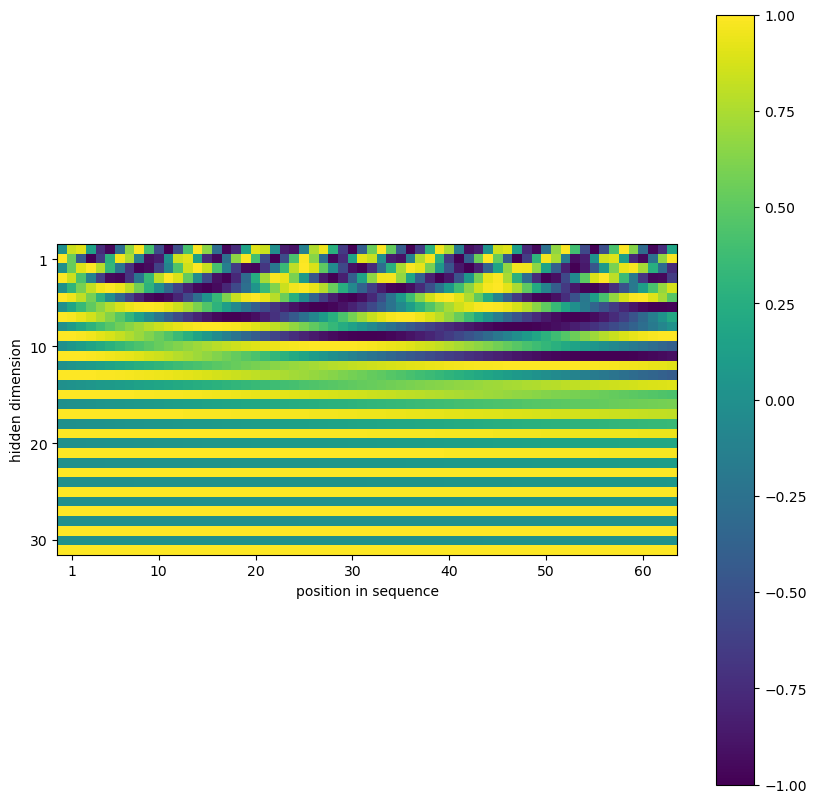

In [178]:
plot_matrix(pe.T.numpy(), xlabel="position in sequence", ylabel="hidden dimension")

finally, we add positional encoding to token embeddings to incorporate positional information.

In [ ]:
x = input_embeddings + pe

with BPE and Positional encoding, we now have way to represent text as ordered numerical vectors. but how do we produce the output text? we can do this by outputing a probability distribution over the entire vocabulary size.

The following 2 layer neural network shows how we can input text into a neural network and get text out.

In [ ]:
w1 = torch.randn(emb_dim, emb_dim, dtype=torch.float32)
b1 = torch.randn(emb_dim)

w2 = torch.randn(emb_dim, vocab_size, dtype=torch.float32)
b2 = torch.randn(vocab_size)

output = x @ w1 + b1
print(output.size())
output = nn.ReLU()(output)
print(output.size())

output = output @ w2 + b2
output = F.softmax(output, dim=-1)

In [ ]:
output.argmax(1)

In [ ]:
print([id2token[i] for i in output.argmax(1).tolist()])

## Self Attention

self-attention can be formulated as:

$$
\mathrm{Attention}(Q, K, V) = \mathrm{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V = Z
$$

The $Q, K,$ and $V$ matrices are generated by projecting the input $X$ via learnable weight matrices $W^Q, W^K,$ and $W^V$

\begin{aligned}
Q &= X W^Q \\
K &= X W^K \\
V &= X W^V
\end{aligned}

### How attention is implemented
in practice, self-attention is implemented efficiently as shown below

In [ ]:
wk = torch.randn(emb_dim, emb_dim, dtype=torch.float32)
wq = torch.randn(emb_dim, emb_dim, dtype=torch.float32)
wv = torch.randn(emb_dim, emb_dim, dtype=torch.float32)

In [ ]:
wk.size(), wq.size(), wv.size()

In [ ]:
k = x @ wk
q = x @ wq
v = x @ wv

k.size(), q.size(), v.size()

In [ ]:
scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(q.size(-1))
scores.size()

In [ ]:
attn_weights = F.softmax(scores, dim=-1)

In [ ]:
output = attn_weights @ v

In [ ]:
plot_matrix(attn_weights.numpy(), xlabel="position in sequence",
            ylabel="position in sequence", figsize=(6, 6))

we can combine it all into a single function:

In [ ]:
def scaled_dot_product_attention(q, k, v, mask=None):
  d_k = q.size(-1)
  scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(d_k)

  if mask is not None:
    scores = scores.masked_fill(mask == 0, float('-inf'))
    
  attn_weights = F.softmax(scores, dim=-1)
  output = torch.matmul(attn_weights, v)
  return output, attn_weights

In [ ]:
output, attn_weights = scaled_dot_product_attention(q, k, v, mask=torch.Tensor(attention_mask).long())
output.size(), attn_weights.size()

### Attention Masks

Attention masks restrict which tokens can be attended to.
A typical example is the causal mask, which allows attention only to previous tokens, enabling the model to learn causal relationships.

Commonly used in time-series and language modeling.

In [ ]:
causal_mask = torch.tril(torch.ones(max_len, max_len))

plot_matrix(causal_mask.numpy(), xlabel="position in sequence",
            ylabel="position in sequence", figsize=(6, 6))

### Multi-head Attention

since tokens can have multiple relationships, multi-head attention uses several attention heads to capture different patterns (e.g., syntax or semantics).

suppose there are $h$ heads. each head has independent projection matrices $W_i^Q$, $W_i^K$, $W_i^V$ for query, key, and value:

$$
\text{head}_i = \mathrm{Attention}(QW_i^Q,\; KW_i^K,\; VW_i^V)
$$

$$
\mathrm{MultiHead}(Q, K, V) = \mathrm{Concat}(\text{head}_1, \ldots, \text{head}_h) W^O
$$


* $h$: number of heads
* $W^O$: output projection matrix



the following is the full implementation of multi-head attention as a PyTorch module.

In [ ]:
class MultiHeadAttentionManual(nn.Module):
  """manual implementation of multi-head attention: split d_model into h subspaces"""
  def __init__(self, d_model, h):
    super().__init__()
    assert d_model % h == 0, "d_model must be divisible by num_heads"
    self.d_model = d_model
    self.num_heads = h
    self.head_dim = d_model // h  # dimension per head


    # QKV projections: input d_model, output d_model (contains projections for all heads)
    self.W_Q = nn.Linear(d_model, d_model)
    self.W_K = nn.Linear(d_model, d_model)
    self.W_V = nn.Linear(d_model, d_model)
    self.W_O = nn.Linear(d_model, d_model)

  def forward(self, q, k, v, mask=None):
    batch_size, seq_len = q.size(0), q.size(1)

    # step 1: linear projections
    q = self.W_Q(q)  # (batch, seq_len, d_model)
    k = self.W_K(k)
    v = self.W_V(v)

    # step 2: reshape to multi-head shape and transpose to put head dim before seq_len
    # (batch, seq_len, d_model) -> (batch, seq_len, num_heads, head_dim)
    # -> (batch, num_heads, seq_len, head_dim)
    q = q.view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)
    k = k.view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)
    v = v.view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)

    # step 3: each head computes attention scores independently
    # Q @ K^T: (batch, num_heads, seq_len, head_dim)
    #        @ (batch, num_heads, head_dim, seq_len)
    #        = (batch, num_heads, seq_len, seq_len)
    scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(self.head_dim)

    # step 4: optional causal masking
    if mask is not None:
      scores = scores.masked_fill(mask == 0, float('-inf'))

    # step 5: softmax + weighted sum
    attn_weights = F.softmax(scores, dim=-1)
    # (batch, num_heads, seq_len, seq_len) @ (batch, num_heads, seq_len, head_dim)
    # = (batch, num_heads, seq_len, head_dim)
    output = torch.matmul(attn_weights, v)

    # step 6: concatenate heads: transpose back to (batch, seq_len, num_heads, head_dim), then merge last two dims
    output = output.transpose(1, 2).contiguous().view(batch_size, seq_len, self.d_model)

    # step 7: apply a final linear
    output = self.W_O(output)  # (batch, seq_len, d_model)
    return output

alternatively, use `scaled_dot_product_attention` to simplify the forward method.

In [ ]:
class MultiHeadAttention(nn.Module):
  """manual implementation of multi-head attention: split d_model into h subspaces"""
  def __init__(self, d_model, h):
    super().__init__()
    assert d_model % h == 0, "d_model must be divisible by num_heads"
    self.d_model = d_model
    self.num_heads = h
    self.head_dim = d_model // h  # dimension per head


    # QKV projections: input d_model, output d_model (contains projections for all heads)
    self.W_Q = nn.Linear(d_model, d_model)
    self.W_K = nn.Linear(d_model, d_model)
    self.W_V = nn.Linear(d_model, d_model)
    self.W_O = nn.Linear(d_model, d_model)

  def forward(self, q, k, v, mask=None):
    batch_size, seq_len = q.size(0), q.size(1)

    # step 1: linear projections
    q = self.W_Q(q)  # (batch, seq_len, d_model)
    k = self.W_K(k)
    v = self.W_V(v)

    # step 2: reshape to multi-head shape and transpose to put head dim before seq_len
    # (batch, seq_len, d_model) -> (batch, seq_len, num_heads, head_dim)
    # -> (batch, num_heads, seq_len, head_dim)
    q = q.view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)
    k = k.view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)
    v = v.view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)

    # step 3: each head computes attention scores independently
    # output: (batch, num_heads, seq_len, head_dim)
    output, _ = scaled_dot_product_attention(q, k, v, mask)


    # step 4: concatenate heads: transpose back to (batch, seq_len, num_heads, head_dim), then merge last two dims
    output = output.transpose(1, 2).contiguous().view(batch_size, seq_len, self.d_model)

    # step 5: apply a final linear
    output = self.W_O(output)  # (batch, seq_len, d_model)
    return output

In [ ]:
x = (input_embeddings + pe).unsqueeze(0) # add batch dimenstion

wk = torch.randn(emb_dim, emb_dim, dtype=torch.float32)
wq = torch.randn(emb_dim, emb_dim, dtype=torch.float32)
wv = torch.randn(emb_dim, emb_dim, dtype=torch.float32)

k = x @ wk
q = x @ wq
v = x @ wv


mha = MultiHeadAttention(d_model=emb_dim, h=2)
out = mha(q, k, v, mask=causal_mask.unsqueeze(0).unsqueeze(0))
out.size()

## Position-Wise Feed-Forward Networks

$$
\mathrm{FFN}(x_i) = \max(0, x_i W_1 + b_1)\, W_2 + b_2
$$

- $x_i$ denotes the input vector at position $i$.
- $\max(0, \cdot)$ is the ReLU activation function, used to introduce non-linearity.

In [ ]:
class PositionwiseFeedForward(nn.Module):
  def __init__(self, d_model, d_ff, dropout=0.1):
    """
    Position-Wise Feed-Forward Network.

    Args:
      d_model: input/output dimension
      d_ff: hidden dimension
      dropout: dropout rate (not used in original paper)
    """
    super().__init__()
    self.w_1 = nn.Linear(d_model, d_ff)  # first linear layer
    self.w_2 = nn.Linear(d_ff, d_model)  # second linear layer
    #self.dropout = nn.Dropout(dropout)   # not used in original paper

  def forward(self, x):
    # first linear layer + ReLU, then second linear layer
    return self.w_2(self.w_1(x).relu())  #self.w_2(self.dropout(self.w_1(x).relu()))

**Layer Normalization** and **Residual Connections**. these two ideas enable training of very deep Transformer models.

## Layer Normalization

layer normalization(LayerNorm) ensures stability of training by ensuring the successive layers of a neural network recieve inputs that are "nice" i.e. centered around zero.

this has two benefits: reduce the noise in training and ensures smooth gradients


**difference between BatchNorm and LayerNorm**

if you are familiar with Batch Normalization (BatchNorm), you may wonder how the two differ.

assume the input tensor has shape $(batch\_size, feature\_size)$, where $batch\_size = 32$ and $feature\_size = 512$.

* batch_size: number of samples in a batch
* feature_size: feature dimension of each sample (each sample has 512 features)

each row corresponds to one sample, and each column corresponds to one feature.

**BatchNorm**

BatchNorm normalizes across all samples in a batch. for each column, compute mean and variance over the batch.

for the $j$-th feature (column):

$$
\mu_j = \frac{1}{\text{batch\_size}} \sum_{i=1}^{\text{batch\_size}} x_{i,j}, \quad
\sigma_j^2 = \frac{1}{\text{batch\_size}} \sum_{i=1}^{\text{batch\_size}} (x_{i,j} - \mu_j)^2
$$


**LayerNorm**

LayerNorm normalizes across all features of each sample. for each row (a single sample with $feature\_size$ features), compute mean and variance.

for the $i$-th sample (row):

$$
\mu_i = \frac{1}{\text{feature\_size}} \sum_{j=1}^{\text{feature\_size}} x_{i,j}, \quad
\sigma_i^2 = \frac{1}{\text{feature\_size}} \sum_{j=1}^{\text{feature\_size}} (x_{i,j} - \mu_i)^2
$$

**LayerNorm Computation**

assume the input vector is $x = (x_1, x_2, \dots, x_d)$. the computation of LayerNorm proceeds as follows:

**Compute Mean and Variance**: compute the mean $\mu$ and variance $\sigma^2$:

$$
\mu = \frac{1}{d} \sum_{j=1}^{d} x_j, \quad
\sigma^2 = \frac{1}{d} \sum_{j=1}^{d} (x_j - \mu)^2
$$

**Normalization**: normalize each feature
$$
\hat{x}_i = \frac{x_i - \mu}{\sqrt{\sigma^2 + \epsilon}}
$$

Here, $\epsilon$ is a small constant (e.g., $1e^{-9}$) to prevent division by zero.

**Learnable Parameters**: apply learnable scaling and shifting
$$
\mathrm{Output} = \gamma \hat{x} + \beta
$$

where $\gamma$ and $\beta$ are learnable parameters used to further adjust the normalized output.

after normalization, the mean is 0 and the variance is 1; after applying scaling and shifting, the mean becomes $\beta$ and the variance becomes $\gamma^2$.

the following is the implementation of layer normalization. $gamma$ and $beta$ are learnable parameters

In [ ]:
def layer_norm(x, gamma, beta):
  mean = x.mean(dim=-1, keepdim=True)
  var = ((x - mean) ** 2).mean(dim=-1, keepdim=True)
  std = (var + 1e-9).sqrt()
  y = (x - mean) / std
  y = y * gamma
  y = y + beta
  return y

In [ ]:
class LayerNorm(nn.Module):
  def __init__(self, feature_size, epsilon=1e-9):
    super().__init__()
    self.gamma = nn.Parameter(torch.ones(feature_size)) 
    self.beta = nn.Parameter(torch.zeros(feature_size))
    self.epsilon = epsilon

  def forward(self, x):
    mean = x.mean(dim=-1, keepdim=True)
    std = x.std(dim=-1, keepdim=True)
    return self.gamma * (x - mean) / (std + self.epsilon) + self.beta

In [ ]:
gamma = torch.ones(emb_dim, dtype=torch.float32)
beta = torch.zeros(emb_dim, dtype=torch.float32)

x = input_embeddings + pe
x_normalized = layer_norm(x, gamma, beta)

## Residual connection

instead of each layer's output being the input of the next layer, a layer can add its output to its input and pass it along to the next layer. this type of flow of data in neural networks are called "residual" or "skip" connection. they allow the training of very deep neural networks by removing the problem of "vanishing gradients".

a residual connection is a type of skip connection. it adds the input of a layer directly to its output. the formulation is:

$$
\mathrm{Output} = \mathrm{SubLayer}(x) + x
$$

this connection effectively alleviates the vanishing gradient problem in deep neural network

**Why does it alleviate vanishing gradients ?**

first, we need to understand what vanishing gradients are.
In deep neural networks, gradients are computed via backpropagation:
$$
\frac{\partial \mathcal{L}}{\partial W}
= \frac{\partial \mathcal{L}}{\partial h_n}
\cdot \frac{\partial h_n}{\partial h_{n-1}}
\cdots
\frac{\partial h_1}{\partial W}
$$

as the network depth increases, the repeated multiplication of gradients in the chain rule may cause them to become increasingly small (vanishing gradients) or increasingly large (exploding gradients), making the model difficult to train and converge.

assume the loss is $\mathcal{L}$, and let $\mathrm{SubLayer}(x)$ be denoted as $F(x)$. without residual connections, the gradient is:

$$
\frac{\partial \mathcal{L}}{\partial x}
= \frac{\partial \mathcal{L}}{\partial F(x)}
\cdot \frac{\partial F(x)}{\partial x}
$$

If $\left|\frac{\partial F(x)}{\partial x}\right| < 1$, then as the number of layers increases, the gradient will rapidly shrink, leading to vanishing gradients.

after introducing residual connections, the output becomes $F(x) + x$, and the gradient is:
$$
\frac{\partial \mathcal{L}}{\partial x}
= \frac{\partial \mathcal{L}}{\partial (x + F(x))}
\cdot \left(1 + \frac{\partial F(x)}{\partial x}\right)
$$

here, a constant term $1$ is introduced. This means that even if $\frac{\partial F(x)}{\partial x}$ is small, the gradient can still propagate effectively backward, alleviating the vanishing gradient problem.

In [ ]:
class ResidualConnection(nn.Module):
  def __init__(self, dropout=0.1):
    """
    residual connection with dropout applied to sublayer output.

    Args:
      dropout: dropout probability applied to sublayer output before adding to input.
    """
    super().__init__()
    self.dropout = nn.Dropout(p=dropout)

  def forward(self, x, sublayer):
    """
    forward pass: apply dropout to sublayer output and add to input.

    Args:
      x: input tensor of shape (batch_size, seq_len, d_model).
      sublayer: sublayer module (multi-head attention or feed-forward network).

    Returns:
      tensor after residual connection and dropout, shape (batch_size, seq_len, d_model).
    """
    # apply dropout to sublayer output, then add to input (see paper section 5.4)
    return x + self.dropout(sublayer(x))

## Add & Norm

operational steps: 

* Residual Connection: add the input directly to the output of the sub-layer.
* Layer Normalization: perform normalization on the result of the addition.

the formula is as follows:

$$
\text{Output} = \text{LayerNorm}(x + \text{SubLayer}(x))
$$

In [ ]:
class SublayerConnection(nn.Module):
  def __init__(self, feature_size, dropout=0.1, epsilon=1e-9):
    super().__init__()
    self.residual = ResidualConnection(dropout)  
    self.norm = LayerNorm(feature_size, epsilon)

  def forward(self, x, sublayer):
    return self.norm(self.residual(x, sublayer))

# alternative implementation with layer norm applied after residual connection
class SublayerConnection(nn.Module):
  def __init__(self, feature_size, dropout=0.1, epsilon=1e-9):
    super().__init__()
    self.norm = LayerNorm(feature_size, epsilon)
    self.dropout = nn.Dropout(p=dropout)

  def forward(self, x, sublayer):
    return self.norm(x + self.dropout(sublayer(x)))

the formula for the linear layer is: $\text{Output} = xW^T + b$. its code implementation is as follows:

In [ ]:
in_features = 16    # input dimension
out_features = 32   # output dimension

self.weight = nn.Parameter(torch.randn(out_features, in_features))
self.bias = nn.Parameter(torch.zeros(out_features))

def forward(self, x):
 return torch.matmul(x, self.weight.T) + self.bias

## Embeddings

In [ ]:
class Embeddings(nn.Module):
  def __init__(self, vocab_size, d_model):
    super().__init__()
    self.embed = nn.Embedding(vocab_size, d_model)
    self.d_model = d_model

  def forward(self, x):
    """
    forward pass function.

    Args:
      x: input tensor of shape (batch_size, seq_len), where each element is a token ID.

    Returns:
      scaled embedding vectors of shape (batch_size, seq_len, d_model).
    """
    return self.embed(x) * math.sqrt(self.d_model)

nn.Embedding() essentially creates a matrix where each row is a vector for a token

In [ ]:
torch.manual_seed(42)

# nn.Embedding() weight matrix shape is (num_embeddings, embedding_dim)
num_embeddings = 5  # assume 5 tokens
embedding_dim = 3   # the size of each embedding vector

# initialize embedding layer
embedding = nn.Embedding(num_embeddings, embedding_dim)

# integer indices
input_indices = torch.tensor([0, 2, 4])

# lookup embeddings
output = embedding(input_indices)

print("wweight matrix:")
print(embedding.weight.data)
print("\nembedding output:")
print(output)

## Softmax

softmax maps a vector to a probability distribution, where each element lies in $[0, 1]$ and the total sums to 1. Its definition is:

$$
\mathrm{softmax}(x_i) = \frac{e^{x_i}}{\sum_{j=1}^{n} e^{x_j}}
$$

- $x_i$ denotes the $i$-th element of the input vector.
- $\mathrm{softmax}(x_i)$ denotes the probability corresponding to $x_i$ after the transformation.

in practice, you can use `torch.nn.functional.softmax` (`F.softmax`)  directly. Here, we implement a simple version manually and compare the results for clarity.

In [ ]:
def softmax(x):
  exp_x = torch.exp(x)
  sum_exp_x = torch.sum(exp_x, dim=-1, keepdim=True)
  return exp_x / sum_exp_x

x = torch.tensor([1.0, 2.0, 3.0])
result = softmax(x)

nn_result = F.softmax(x, dim=-1)

print("manual softmax results:", result)
print("F.softmax results:", nn_result)

## Positional Encoding

in Transformer, since there is no recurrent structure (like RNNs), the model cannot capture positional information on its own. recall that attention scores are computed from dot products between queries and keys, so the resulting attention weights depend only on content, not position.

for example, changing ["A", "B", "C"] to ["B", "A", "C"] simply permutes the output. if the original output is $[Z_A, Z_B, Z_C]$, the new output becomes $[Z_B, Z_A, Z_C]$.

therefore, without positional information in embeddings, the model is insensitive to sequence order—it only rearranges outputs without changing their values.

to address this, Transformer introduces **Positional Encoding**, which adds a position-specific vector to each embedding.

in the original paper, positional encoding is defined as:

$$
\begin{aligned}
PE_{(pos, 2i)} = \sin\left(\frac{pos}{10000^{2i / d_{model}}}\right) \\
PE_{(pos, 2i+1)} = \cos\left(\frac{pos}{10000^{2i / d_{model}}}\right)
\end{aligned}
$$

where $pos$ represents the position of the word in the sequence, $d_{model}$ denotes the dimensionality of the positional encoding (PE), and $i$ indexes the embedding dimensions (in pairs).


In [ ]:
class PositionalEncoding(nn.Module):
  def __init__(self, d_model, dropout=0.1, max_len=5000):
    super().__init__()
    self.dropout = nn.Dropout(p=dropout)
    
    pe = torch.zeros(max_len, d_model)
    position = torch.arange(0, max_len).unsqueeze(1)  #(max_len, 1)
    
    div_term = torch.exp(
      torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model)
    )
    
    pe[:, 0::2] = torch.sin(position * div_term)
    pe[:, 1::2] = torch.cos(position * div_term)
    
    pe = pe.unsqueeze(0) #(1, max_len, d_model)
    
    self.register_buffer('pe', pe)
  
  def forward(self, x):
    x = x + self.pe[:, :x.size(1), :] # x: (batch_size, seq_len, d_model)
    return self.dropout(x)

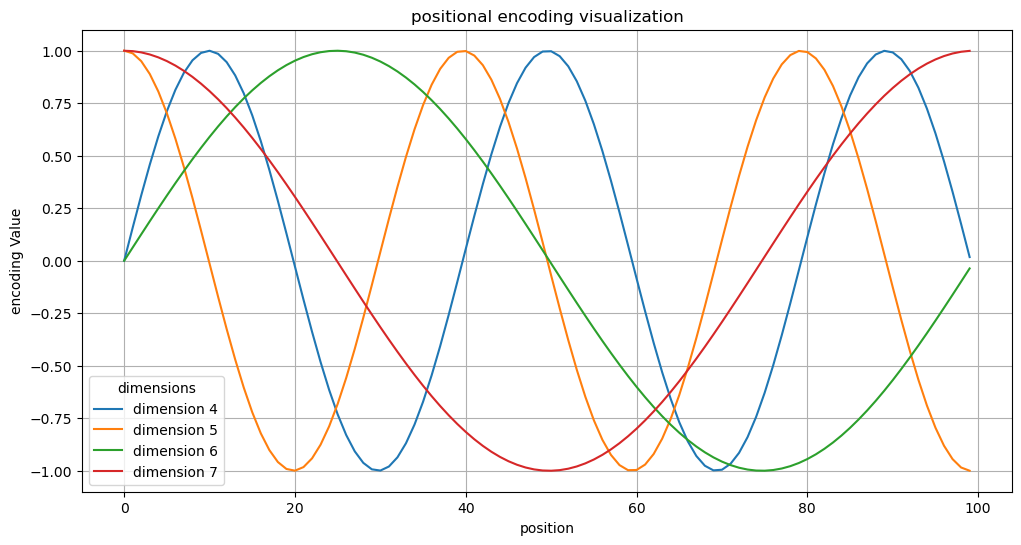

In [179]:
def visualize_positional_encoding():
  pe = PositionalEncoding(20, dropout=0, max_len=100)
  x = torch.zeros(1, 100, 20)
  y = pe.forward(x)


  plt.figure(figsize=(12, 6))
  # plot dimensions 4, 5, 6, 7 to visualize
  for dim in [4, 5, 6, 7]:
    plt.plot(range(100), y[0, :, dim].numpy(), label=f'dimension {dim}')
  
  plt.title("positional encoding visualization")
  plt.xlabel("position")
  plt.ylabel("encoding Value")
  plt.legend(title="dimensions")
  plt.grid(True)

  # save PNG image
  # plt.savefig("positional_encoding.png", format="png", dpi=300, bbox_inches='tight')
  plt.show()

visualize_positional_encoding()

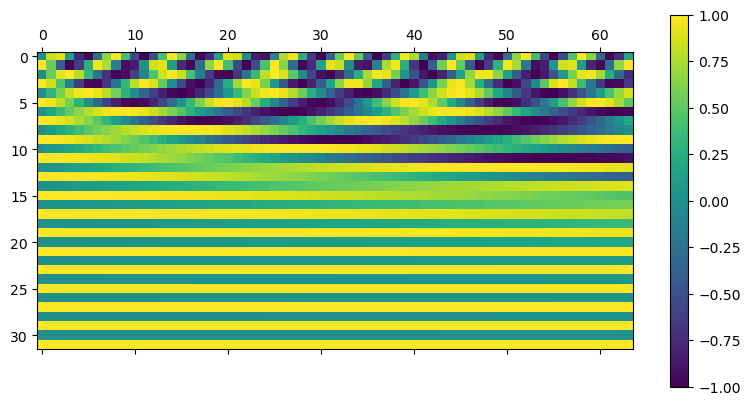

In [180]:
pe = PositionalEncoding(32, dropout=0, max_len=100)
x = torch.zeros(1, 64, 32)
y = pe(x).squeeze(0).T # (1, max_len, d_model) -> (max_len, d_model) -> (d_model, max_len)

im = plt.matshow(y)
plt.gcf().colorbar(im)
# plt.savefig('sinusoidal.png')

$$
\begin{aligned}
PE(pos, 2i)   &= \sin(pos \cdot \omega_i) \\
PE(pos, 2i+1) &= \cos(pos \cdot \omega_i) \\
\omega_i      &= \frac{1}{10000^{\frac{2i}{d_{\text{model}}}}}
\end{aligned}
$$

from the previous two figures, we can see that smaller i (lower dimensions) correspond to higher frequencies, while larger i (higher dimensions) correspond to lower frequencies.

another property of positional encoding is that position vectors are linearly related. this allows us not only to represent the absolute position of a token, but also to capture relative positions.

consider a shift $k$: 

$$
\begin{aligned}
&PE(pos + k, 2i) = \sin\big((pos + k)\omega_i\big) = \sin(pos\omega_i)\cos(k\omega_i) + \cos(pos\omega_i)\sin(k\omega_i) \\[6pt]
&PE(pos + k, 2i+1) = \cos\big((pos + k)\omega_i\big) = \cos(pos\omega_i)\cos(k\omega_i) - \sin(pos\omega_i)\sin(k\omega_i) \\[10pt]
\end{aligned}
$$

vector form:

$$
\begin{aligned}

\begin{bmatrix}
PE(pos + k, 2i) \\
PE(pos + k, 2i+1)
\end{bmatrix}

=

\begin{bmatrix}
\cos(k\omega_i) & \sin(k\omega_i) \\
-\sin(k\omega_i) & \cos(k\omega_i)
\end{bmatrix}
\begin{bmatrix}
PE(pos, 2i) \\
PE(pos, 2i+1)
\end{bmatrix} \\

\end{aligned}
$$

therefore,

$$
\begin{aligned}
&PE(pos + k) =
\begin{bmatrix}
\cos(k\omega_i) & \sin(k\omega_i) \\
-\sin(k\omega_i) & \cos(k\omega_i)
\end{bmatrix}
\cdot
PE(pos)
\end{aligned}
$$

## Source Embedding

the input to the encoder consists of input embeddings and positional encoding. in machine translation tasks, this is also referred to as source embeddings.

In [ ]:
class SourceEmbedding(nn.Module):
  def __init__(self, src_vocab_size, d_model, dropout=0.1):
    super().__init__()
    self.embed = Embeddings(src_vocab_size, d_model)
    self.positional_encoding = PositionalEncoding(d_model, dropout)

  def forward(self, x):
    x = self.embed(x)  # map token IDs to embedding vectors: (batch_size, seq_len) -> (batch_size, seq_len, d_model)
    return self.positional_encoding(x)

## Target Embedding

the input to the decoder consists of output embeddings and positional encoding. in machine translation, this is also referred to as target embeddings.

In [ ]:
class TargetEmbedding(nn.Module):
  def __init__(self, target_vocab_size, d_model, dropout=0.1):
    super().__init__()
    self.embed = Embeddings(target_vocab_size, d_model)  
    self.positional_encoding = PositionalEncoding(d_model, dropout)

  def forward(self, x):
    x = self.embed(x) # map token IDs to embedding vectors: (batch_size, seq_len) -> (batch_size, seq_len, d_model)
    return self.positional_encoding(x)

## Mask

### Padding Mask

when processing variable-length sequences, we usually pad shorter sequences with special tokens (e.g., `<pad>`) to make all sequences in a batch have the same length.

In [ ]:
def create_padding_mask(seq, pad_token=0):
  # seq: (batch_size, seq_len)
  mask = (seq != pad_token).unsqueeze(1).unsqueeze(2)  # (batch_size, 1, 1, seq_len)
  return mask

the mask is created at the token ID level—after tokenization but before embedding.

example:
suppose we have the following two sequences after tokenization and mapping to token IDs

In [ ]:
seq = torch.tensor([[5, 7, 9, 0, 0], [8, 6, 0, 0, 0]]) # 0 represents <PAD>
print(create_padding_mask(seq))

### Causal Mask

a causal mask ensures that each position in a sequence can only attend to itself and earlier positions, not future ones

In [ ]:
def create_causal_mask(seq_len):
  mask = torch.tril(torch.ones(seq_len, seq_len)).bool() # lower triangular matrix
  return mask  # (seq_len, seq_len)

In [ ]:
# or a sequence length of 5:
print(create_causal_mask(5))

### Combined Mask:
in practice, we combine the padding mask and the causal mask to apply both effects at the same time—masking out padding tokens and preventing access to future positions.

In [ ]:
def create_decoder_mask(tgt_seq, pad_token=0):
  padding_mask = create_padding_mask(tgt_seq, pad_token) # (batch_size, 1, 1, tgt_seq_len)
  causal_mask_mask = create_causal_mask(tgt_seq.size(1)).to(tgt_seq.device)  # (tgt_seq_len, tgt_seq_len)

  combined_mask = causal_mask_mask.unsqueeze(0) & padding_mask  # (batch_size, 1, tgt_seq_len, tgt_seq_len)
  return combined_mask

example:

suppose the target sequence tgt_seq is:

In [ ]:
tgt_seq = torch.tensor([[1, 2, 3, 4, 0]])  # 0 represents <PAD>
print(create_decoder_mask(tgt_seq))

## Encoder Layer

an **Encoder Layer** in a Transformer is built from three main components, stacked in a specific order:
- Multi-Head Attention
- Feed-Forward Network (FFN)
- Residual Connection + Layer Normalization (**Add & Norm**). together often called a **SublayerConnection**

In [ ]:
class EncoderLayer(nn.Module):
  def __init__(self, d_model, h, d_ff, dropout):
    """
    args:
      d_model: embedding dimension
      h: number of attention heads
      d_ff: hidden dimension of feed-forward network
      dropout: dropout probability
    """
    super().__init__()
    self.self_attn = MultiHeadAttention(d_model, h)
    self.feed_forward = PositionwiseFeedForward(d_model, d_ff, dropout)
    
    # define two sublayer connections for multi-head attention and feed-forward network
    self.sublayers = nn.ModuleList([SublayerConnection(d_model, dropout) for _ in range(2)])
    self.d_model = d_model

  def forward(self, x, src_mask):
    """
    args:
      x: input tensor of shape (batch_size, seq_len, d_model).
      src_mask: source sequence mask for self-attention.

    returns:
      output of encoder layer, shape (batch_size, seq_len, d_model).
    """
    x = self.sublayers[0](x, lambda x: self.self_attn(x, x, x, src_mask))  # self-attention sublayer
    x = self.sublayers[1](x, self.feed_forward)  # feed-forward sublayer
    return x